In [ ]:
%pip install -q geopandas plotly scikit-learn pandas numpy matplotlib seaborn scipy

# Global Cluster Profile: Seasonal Yearly Evolution

In this notebook, the pair *season-city* is clustered yer-per-year, to track seasonal evolution and analyze intra-annual climate variability among world capitals.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
import geopandas as gpd
import plotly.graph_objects as go
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import ipywidgets as widgets
from IPython.display import display
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')

# Loading pre-processed data

We load the pre-processed climate history dataset, the mapping file that connects capital cities to their respective countries and the mapping files that connect capital cities to their respective latitude and longitude.

In [ ]:
df = pd.read_parquet("cleaned_history.parquet")

with open("capital_to_country.json", "r") as f:
    capital_to_country = json.load(f)

with open("capital_to_lat.json", "r") as f:
    capital_to_lat = json.load(f)

with open("capital_to_lon.json", "r") as f:
    capital_to_lon = json.load(f)

print("Files successfully loaded!")

Files successfully loaded!


In [ ]:
aggregation_per_season_anno = df.groupby(['capital', 'season', 'year']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

aggregation_per_season_anno.to_csv('aggregation_per_season_anno.csv', index=False)

For every year and for ever capital, we have four records, representing summary statistics for that precise capital in that season.

In [ ]:
aggregation_per_season_anno['capital_in_season'] = aggregation_per_season_anno['capital'] + '_in_' + aggregation_per_season_anno['season']
aggregation_per_season_anno.head(5)


,capital,season,year,mean_temp,std_temp,rain_total,days_rain,snow_total,days_snow,mean_daylight,mean_sunshine,capital_in_season
0,Abuja,Autumn,1995,25.346154,0.997280,612.4,55,0.0,0,42978.835824,32718.242088,Abuja_in_Autumn
1,Abuja,Autumn,1996,25.509341,1.265436,474.1,46,0.0,0,42959.122637,32873.976264,Abuja_in_Autumn
2,Abuja,Autumn,1997,25.830769,0.813899,446.4,57,0.0,0,42965.378022,34445.164505,Abuja_in_Autumn
3,Abuja,Autumn,1998,25.974176,1.551457,352.3,48,0.0,0,42971.698022,33180.944396,Abuja_in_Autumn
4,Abuja,Autumn,1999,25.309341,1.502385,457.3,56,0.0,0,42978.140659,31762.499890,Abuja_in_Autumn


# Clusterization and re-alignment

To solve label switching problem, we re-align year-by-year cluster indexes with the same Hungarian Algorithm strategy described in previous notebook.

In [ ]:
def align_clusters_sequentially(df_clusters_dict, raw_means_dict, scaled_means_dict, years, features, n_clusters=5):
    """
    Aligns clusters sequentially across years: each year is aligned to the previous one
    based on the Euclidean distance between pre-NORMALIZED centroids.
    The first year defines the baseline reference labels.

    Args:
        df_clusters_dict (dict): Dictionary mapping years to DataFrames containing a 'cluster' column.
        raw_means_dict (dict): Dictionary mapping years to DataFrames of raw (unscaled) cluster centroids.
        scaled_means_dict (dict): Dictionary mapping years to DataFrames of scaled cluster centroids.
        years (list): Ordered list of years (e.g., [1995, 1996, ..., 2024]).
        features (list): List of feature names used for distance calculation.
        n_clusters (int): The fixed number of clusters expected each year.

    Returns:
        tuple: (aligned_clusters_dict, aligned_raw_means_dict)
    """

    aligned_clusters = {}
    aligned_raw_means = {}
    aligned_scaled_means = {}

    # The first year remains unchanged and acts as the absolute baseline
    aligned_clusters[years[0]] = df_clusters_dict[years[0]].copy()
    aligned_raw_means[years[0]] = raw_means_dict[years[0]].copy()
    aligned_scaled_means[years[0]] = scaled_means_dict[years[0]].copy()

    print("=" * 80)
    print("CLEAN SEQUENTIAL CLUSTER ALIGNMENT")
    print("=" * 80)
    print(f"\n{years[0]}: Initial Baseline (No remapping)")

    # Iterate through subsequent years to align them sequentially
    for i in range(1, len(years)):
        prev_year = years[i-1]
        curr_year = years[i]

        # 1. Extract SCALED centroids (the previous year's centroids are already aligned)
        prev_centroids_scaled = aligned_scaled_means[prev_year][features].values
        curr_centroids_scaled = scaled_means_dict[curr_year][features].values

        # Enforce fixed cluster count to ensure distance matrix is square (N x N)
        assert len(prev_centroids_scaled) == n_clusters, f"Expected {n_clusters} clusters, found {len(prev_centroids_scaled)}"
        assert len(curr_centroids_scaled) == n_clusters, f"Expected {n_clusters} clusters, found {len(curr_centroids_scaled)}"

        # 2. Calculate the Euclidean distance matrix directly on the scaled centroids generated by K-Means
        # Rows = current clusters, Columns = previous clusters
        distances = cdist(curr_centroids_scaled, prev_centroids_scaled, metric='euclidean')

        # 3. Apply the Hungarian algorithm to find the optimal 1-to-1 global assignment
        row_ind, col_ind = linear_sum_assignment(distances)

        # Create a mapping dictionary: {current_cluster_id: previous_cluster_id}
        mapping = {curr_cluster: prev_cluster for curr_cluster, prev_cluster in zip(row_ind, col_ind)}

        # 4. Apply the mapping to the main DataFrame containing the data points
        df_aligned = df_clusters_dict[curr_year].copy()
        df_aligned['cluster'] = df_aligned['cluster'].map(mapping)
        aligned_clusters[curr_year] = df_aligned

        # 5. Recalculate the RAW means (for output/interpretability) based on the newly aligned labels
        aligned_raw_means[curr_year] = df_aligned.groupby('cluster')[features].mean()

        # 6. Apply the mapping to the scaled centroids to prepare them for the next iteration step
        scaled_aligned_df = scaled_means_dict[curr_year].copy().reset_index()
        scaled_aligned_df['cluster'] = scaled_aligned_df['cluster'].map(mapping)
        aligned_scaled_means[curr_year] = scaled_aligned_df.groupby('cluster')[features].mean()

        print(f"[{curr_year} → {prev_year}] Mapping: {mapping}")

    print("\n" + "=" * 80)
    print("SEQUENTIAL ALIGNMENT COMPLETED")
    print("=" * 80)

    return aligned_clusters, aligned_raw_means

This execution block orchestrates the year-by-year clustering from 1995 to 2024 of the various seasons.

For each year, it applies log transformations to skewed precipitation variables, standardizes the dataset and runs K-Means clustering ($K=5$). Crucially, it extracts two sets of centroids: the unnormalized means to preserve real meteorological values for dashboards, and the scaled means to ensure mathematically consistent distance tracking.

Finally, it feeds these dictionaries into the sequential alignment function to resolve label switching, maintaining perfect historical continuity before exporting the aligned results to CSV files.

In [ ]:
# Execute sequential alignment on the ORIGINAL data (before any manual remapping)
# First, recreate the original clusters without remapping

# List of years to process
years = list(range(1995, 2025))

# Features to use for clustering
features = ['mean_temp', 'std_temp', 'rain_total', 'days_rain', 'snow_total', 'days_snow', 'mean_sunshine', 'mean_daylight']

# Number of clusters chosen
k = 5

# Dictionaries to store the outputs per year
df_clusters_original = {}
cluster_means_original = {}
cluster_scaled_means_original = {}

for year in years:
    # Filter data for the current year
    df_year = aggregation_per_season_anno[aggregation_per_season_anno['year'] == year].copy()

    # Prepare the data for clustering
    X = df_year[features].copy()
    X["rain_total"] = np.log1p(X["rain_total"])
    X["snow_total"] = np.log1p(X["snow_total"])

    # Scale the features (Standardization)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Perform K-Means clustering on the scaled data
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    df_year["cluster"] = kmeans.fit_predict(X_scaled)

    # Add country, latitude, and longitude metadata (needed for the dashboard)
    df_year['country'] = df_year['capital'].map(capital_to_country)
    df_year['lat'] = df_year['capital'].map(capital_to_lat)
    df_year['lon'] = df_year['capital'].map(capital_to_lon)

    # Save the original dataframe containing the raw data and cluster labels
    df_clusters_original[year] = df_year

    # Calculate UNNORMALIZED (raw) means for interpretability and CSV saving
    cluster_means_original[year] = df_year.groupby('cluster')[features].mean()

    # Calculate NORMALIZED (scaled) means to feed the alignment algorithm
    X_scaled_df = pd.DataFrame(X_scaled, columns=features)
    X_scaled_df['cluster'] = df_year["cluster"].values
    cluster_scaled_means_original[year] = X_scaled_df.groupby('cluster')[features].mean()


For consistency, we are going to remap the cluster index, so that Cluster indexs here indicate the same grouping as in the previous notebooks.

In [ ]:
manual_mapping = {0: 3, 1: 2, 2: 0, 3: 4, 4: 1}
base_year = years[0]

print(f"Applying manual cluster remapping to the baseline year ({base_year})...")

# 1. Remap the cluster column in the main dataframe for the base year
df_clusters_original[base_year]['cluster'] = df_clusters_original[base_year]['cluster'].map(manual_mapping)

# 2. Remap the index of the raw (unnormalized) means dataframe and sort
cluster_means_original[base_year].index = cluster_means_original[base_year].index.map(manual_mapping)
cluster_means_original[base_year] = cluster_means_original[base_year].sort_index()

# 3. Remap the index of the scaled means dataframe and sort
cluster_scaled_means_original[base_year].index = cluster_scaled_means_original[base_year].index.map(manual_mapping)
cluster_scaled_means_original[base_year] = cluster_scaled_means_original[base_year].sort_index()

print("Baseline remapping successful! Ready for sequential alignment.")

Applying manual cluster remapping to the baseline year (1995)...
Baseline remapping successful! Ready for sequential alignment.


In [ ]:
# Now apply the sequential alignment using the clean function
df_clusters_anni, cluster_means_anni = align_clusters_sequentially(
    df_clusters_dict=df_clusters_original,
    raw_means_dict=cluster_means_original,
    scaled_means_dict=cluster_scaled_means_original,
    years=years,
    features=features,
    n_clusters=k
)

print("\n" + "="*80)
print("Clusters are now sequentially aligned!")
print("Each year has been mapped to the previous one based on the Euclidean distance")
print("calculated directly on the pre-NORMALIZED K-Means centroids.")
print("="*80)

# Save the aligned results to CSV files
for year in years:
    df_clusters_anni[year].to_csv(f'clusterization_{year}.csv', index=False)
    cluster_means_anni[year].to_csv(f'clusterization_means_{year}.csv', index=False)

CLEAN SEQUENTIAL CLUSTER ALIGNMENT

1995: Initial Baseline (No remapping)
[1996 → 1995] Mapping: {np.int64(0): np.int64(3), np.int64(1): np.int64(0), np.int64(2): np.int64(4), np.int64(3): np.int64(2), np.int64(4): np.int64(1)}
[1997 → 1996] Mapping: {np.int64(0): np.int64(4), np.int64(1): np.int64(3), np.int64(2): np.int64(0), np.int64(3): np.int64(1), np.int64(4): np.int64(2)}
[1998 → 1997] Mapping: {np.int64(0): np.int64(3), np.int64(1): np.int64(2), np.int64(2): np.int64(0), np.int64(3): np.int64(4), np.int64(4): np.int64(1)}
[1999 → 1998] Mapping: {np.int64(0): np.int64(3), np.int64(1): np.int64(2), np.int64(2): np.int64(4), np.int64(3): np.int64(0), np.int64(4): np.int64(1)}
[2000 → 1999] Mapping: {np.int64(0): np.int64(4), np.int64(1): np.int64(1), np.int64(2): np.int64(3), np.int64(3): np.int64(0), np.int64(4): np.int64(2)}
[2001 → 2000] Mapping: {np.int64(0): np.int64(3), np.int64(1): np.int64(1), np.int64(2): np.int64(0), np.int64(3): np.int64(2), np.int64(4): np.int64(4)}
[2

# Visual Analysis of Cluster Profiles

Let analyse visually cluster composition with world maps, boxplots and line chart for summarize centroids statistics.

In [ ]:
cmap = plt.get_cmap("tab10")
hex_codes = [mcolors.to_hex(cmap(i)) for i in range(cmap.N)]

my_colors = {i: hex_codes[i] for i in range(len(hex_codes))}
print(my_colors)

{0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c', 3: '#d62728', 4: '#9467bd', 5: '#8c564b', 6: '#e377c2', 7: '#7f7f7f', 8: '#bcbd22', 9: '#17becf'}


In [ ]:
def plot_world_year(df_cluster_assignment, year, season, n_clusters, method="K-Means", colors_to_use=my_colors):
    """
    Visualize world map in specific year
    """

    # World map data
    world_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(world_url)

    # We have some differences in names
    name_mapping = {
        'Bosnia and Herzegovina': 'Bosnia and Herz.',
        'Central African Republic': 'Central African Rep.',
        'Czech Republic': 'Czechia',
        'Democratic Republic of the Congo': 'Dem. Rep. Congo',
        'Dominican Republic': 'Dominican Rep.',
        'Equatorial Guinea': 'Eq. Guinea',
        'Eswatini': 'eSwatini',
        'Ivory Coast': "Côte d'Ivoire",
        'Kingdom of the Netherlands': 'Netherlands',
        "People's Republic of China": 'China',
        'Republic of the Congo': 'Congo',
        'Solomon Islands': 'Solomon Is.'
    }

    df_cluster_assignment['country'] = df_cluster_assignment['country'].replace(name_mapping)
    df_cluster_assignment['cluster'] = df_cluster_assignment['cluster'].astype(int).astype(str)

    df_cluster_assignment = df_cluster_assignment[df_cluster_assignment['season'] == season]

    # Merge data
    world_clusters = world.merge(
        df_cluster_assignment,
        how="left",
        left_on="NAME",
        right_on="country"
    )

    fig, ax = plt.subplots(1, 1, figsize=(18, 9))

    # 1. Map specific colors directly to the rows based on cluster ID
    color_dict = {str(i): colors_to_use[i] for i in range(n_clusters)}
    world_clusters['plot_color'] = world_clusters['cluster'].map(color_dict).fillna('whitesmoke')

    # 2. Plot using the explicit 'color' argument instead of 'column' + 'cmap'
    world_clusters.plot(
        color=world_clusters['plot_color'],
        linewidth=0.5,
        edgecolor="black",
        ax=ax
    )

    # 3. Rebuild the categorical legend manually to maintain consistency
    legend_handles = []
    for i in range(n_clusters):
        legend_handles.append(
            Line2D([0], [0], marker='o', color='w', label=str(i),
                   markerfacecolor=colors_to_use[i], markersize=10)
        )

    # Add the 'No data' item
    legend_handles.append(
        Line2D([0], [0], marker='o', color='w', label='No data',
               markerfacecolor='whitesmoke', markeredgecolor='gray', markersize=10)
    )

    # Place the legend
    ax.legend(handles=legend_handles, loc='upper right')

    ax.set_title(
        f"Climate Clusters - {year} ({method})",
        fontsize=16
    )

    ax.axis("off")
    plt.show()

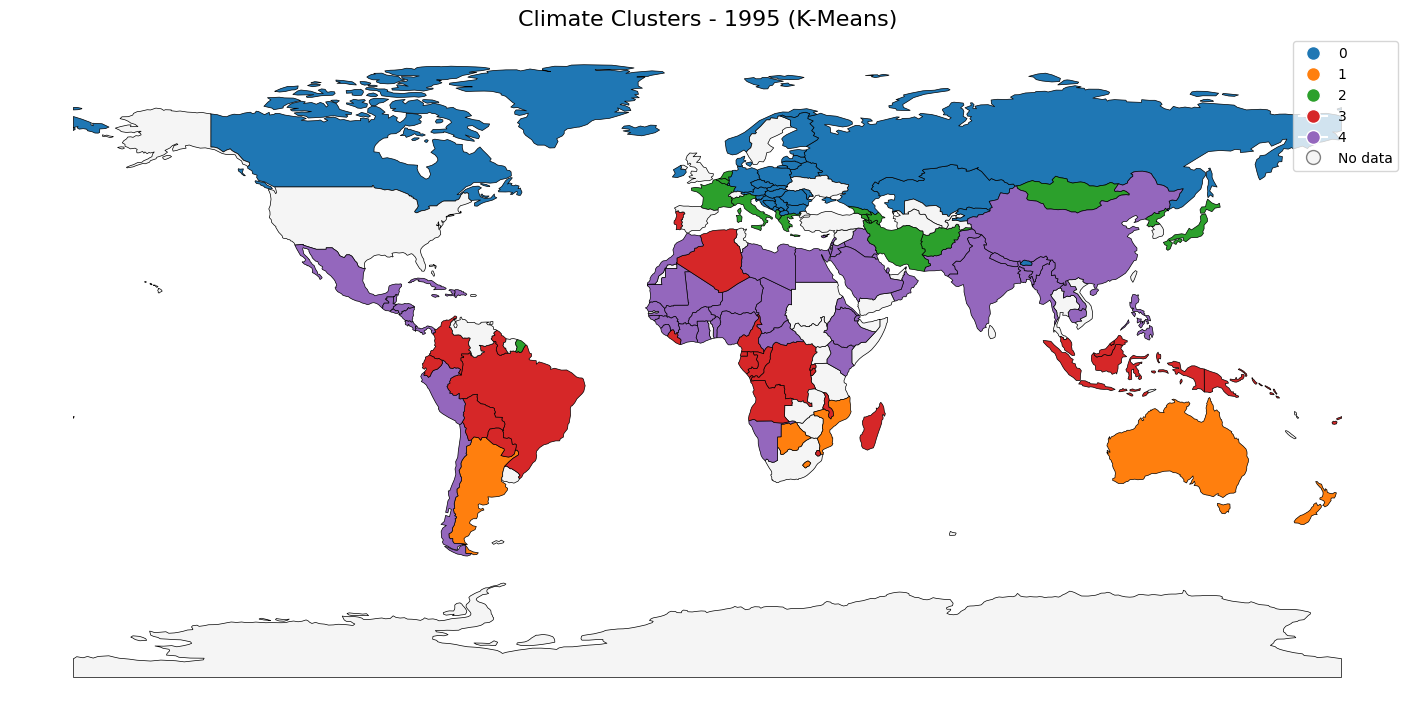

In [ ]:
plot_world_year(df_clusters_anni[1995], 1995, season="Winter", n_clusters=k)

In [ ]:
def plot_world_slider_go(df_clusters_anni, years, n_clusters, method="K-Means", colors_to_use=my_colors, season="Winter"):

    colorscale = []
    for i in range(n_clusters):
        c = colors_to_use[i]
        colorscale.append([i / n_clusters, c])
        colorscale.append([(i + 1) / n_clusters, c])

    frames = []

    for year in years:
        df = df_clusters_anni[year]
        df = df[df["season"] == season]

        frames.append(
            go.Frame(
                data=[
                    go.Choropleth(
                        locations=df["country"],
                        locationmode="country names",
                        z=df["cluster"],
                        zmin=0,
                        zmax=n_clusters - 1,
                        colorscale=colorscale,
                        showscale=True,
                        colorbar=dict(
                            title="Cluster",
                            tickvals=list(range(n_clusters)),
                            len=0.75
                        ),
                        marker_line_color="black",
                        marker_line_width=1.2,
                                                customdata=np.stack(
                            [df["capital"], df["country"], df["cluster"]],
                            axis=-1
                        ),
                        hovertemplate=(
                            "<b>%{customdata[0]}</b><br>"
                            "<span style='font-size:12px'>%{customdata[1]}</span><br>"
                            "Cluster: %{customdata[2]}"
                            "<extra></extra>"
                        ),

                    )
                ],
                name=str(year)
            )
        )

    fig = go.Figure(
        data=frames[0].data,
        layout=go.Layout(
            title=dict(
                text=f"Climate Clusters {years[0]} - {years[-1]} ({method})",
                x=0.5,
                xanchor="center",
                font=dict(size=20)
            ),
            width=1400,
            height=750,
            geo=dict(
                domain=dict(x=[0, 1], y=[0.1, 1]),
                projection_type="natural earth",
                showframe=False,
                showcountries=True,
                countrycolor="black",
                countrywidth=1.2,
                showcoastlines=False,
                bgcolor="white"
            ),

            updatemenus=[{
                "type": "buttons",
                "showactive": False,
                "x": 0.5,
                "y": 0.03,
                "xanchor": "center",
                "direction": "left",
                "buttons": [
                    {
                        "label": "▶ Play",
                        "method": "animate",
                        "args": [
                            None,
                            {
                                "frame": {"duration": 700, "redraw": True},
                                "fromcurrent": True,
                                "transition": {"duration": 300}
                            }
                        ]
                    },
                    {
                        "label": "⏸ Pause",
                        "method": "animate",
                        "args": [
                            [None],
                            {
                                "frame": {"duration": 0, "redraw": False},
                                "mode": "immediate"
                            }
                        ]
                    }
                ]
            }],

            sliders=[{
                "y": 0.05,
                "x": 0.1,
                "len": 0.8,
                "steps": [
                    {
                        "method": "animate",
                        "label": str(year),
                        "args": [
                            [str(year)],
                            {
                                "frame": {"duration": 0, "redraw": True},
                                "mode": "immediate"
                            }
                        ]
                    }
                    for year in years
                ],
                "currentvalue": {
                    "prefix": "Year: ",
                    "font": {"size": 16}
                }
            }]
        ),
        frames=frames
    )

    fig.show()


In [ ]:
years = sorted(df_clusters_anni.keys())

plot_world_slider_go(df_clusters_anni, years, season="Autumn", n_clusters=k)

In [ ]:
def plot_boxplots(df_cluster_assignment, n_clusters, colors_to_use=my_colors):
    # 8 features → 4x2 subplot
    fig, axes = plt.subplots(4, 2, figsize=(20, 15))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        ax = axes[i]

        # Create boxplot with colors
        box_data = [df_cluster_assignment[df_cluster_assignment['cluster'] == c][feature].values for c in range(n_clusters)]
        bp = ax.boxplot(box_data, tick_labels=range(n_clusters), patch_artist=True,
                        medianprops={'color': 'black'}, boxprops={'alpha': 0.7, 'edgecolor': 'black'})

        # Apply colors to boxes
        for patch, cluster_id in zip(bp['boxes'], range(n_clusters)):
            patch.set_facecolor(colors_to_use[cluster_id])

        # Style the plot
        ax.set_title(f'{feature} by Cluster', fontsize=12, fontweight='bold')
        ax.set_xlabel('Cluster', fontsize=10)
        ax.set_ylabel(feature, fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Feature Distribution by Cluster', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()



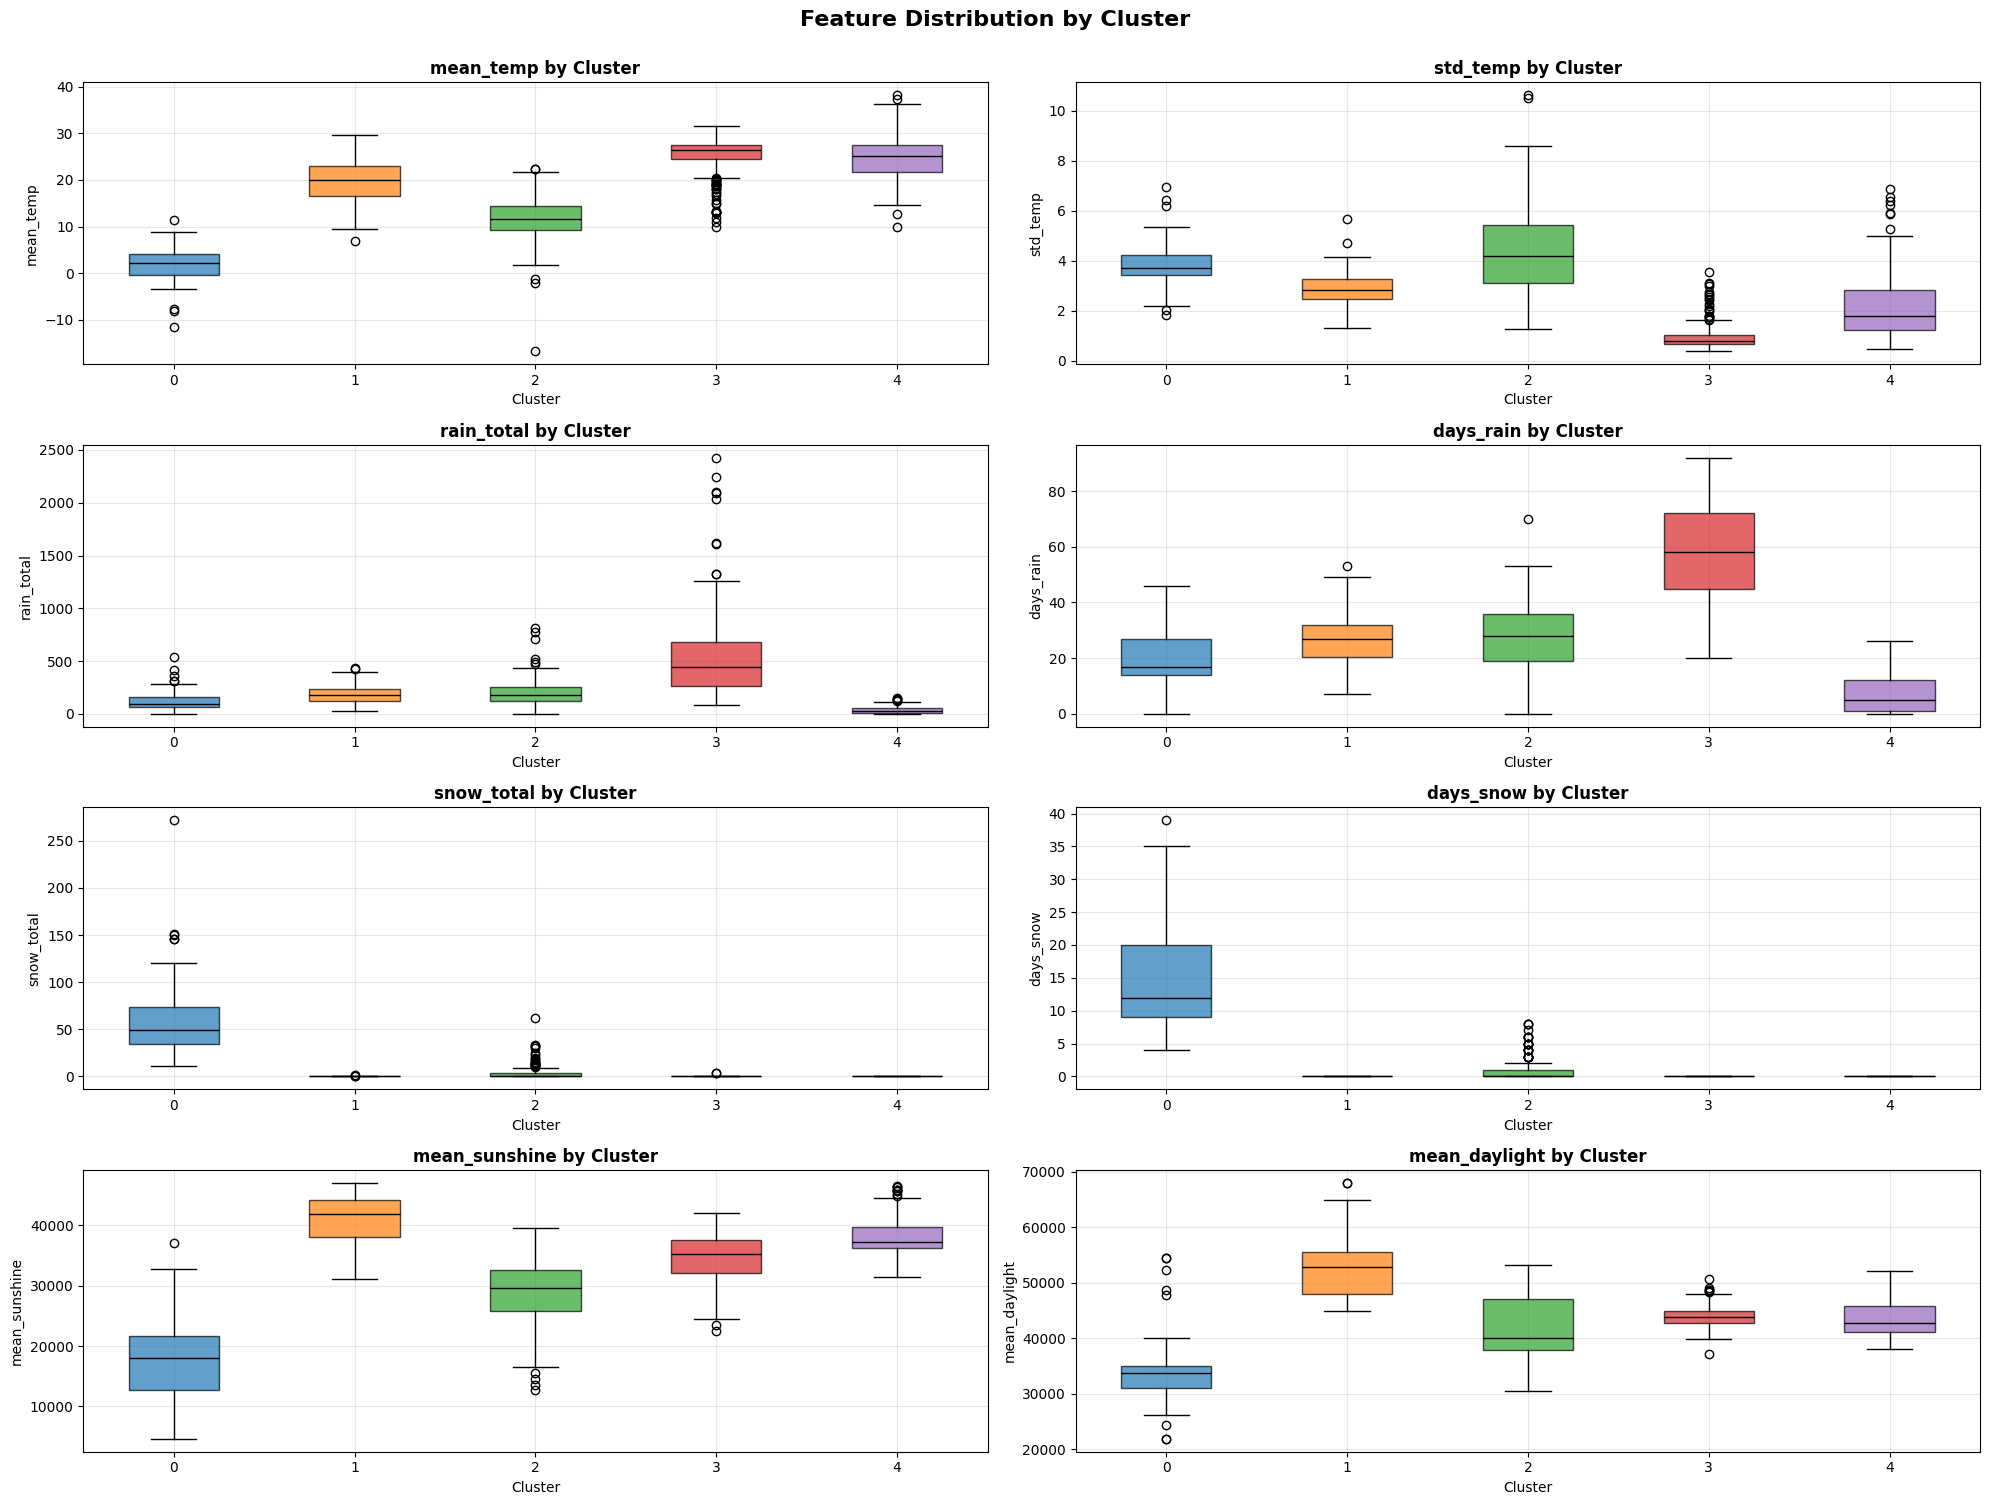

In [ ]:
plot_boxplots(df_clusters_anni[2019], k)

In [ ]:
def plot_evo(df):

    comparison_data_remapped = {}
    for year in years:
        comparison_data_remapped[year] = df[year]['mean_temp']

    comparison_temp_remapped = pd.DataFrame(comparison_data_remapped)

    plt.figure(figsize=(16, 8))
    for cluster_id in range(k):
        if cluster_id in comparison_temp_remapped.index:
            temps = comparison_temp_remapped.loc[cluster_id]
            plt.plot(years, temps, marker='o', label=f'Cluster {cluster_id}', linewidth=2, markersize=8)

    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Mean Temperature (°C)', fontsize=12)
    plt.title(f'Evolution of Mean Temperatures per Cluster Across Years', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    comparison_rain_remapped = {}
    for year in years:
        comparison_rain_remapped[year] = df[year]['rain_total']

    comparison_rain_df = pd.DataFrame(comparison_rain_remapped)

    plt.figure(figsize=(16, 8))
    for cluster_id in range(k):
        if cluster_id in comparison_rain_df.index:
            rains = comparison_rain_df.loc[cluster_id]
            plt.plot(years, rains, marker='o', label=f'Cluster {cluster_id}', linewidth=2, markersize=8)

    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Annual Precipitation (mm)', fontsize=12)
    plt.title(f'Evolution of Annual Precipitation per Cluster Across Years', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

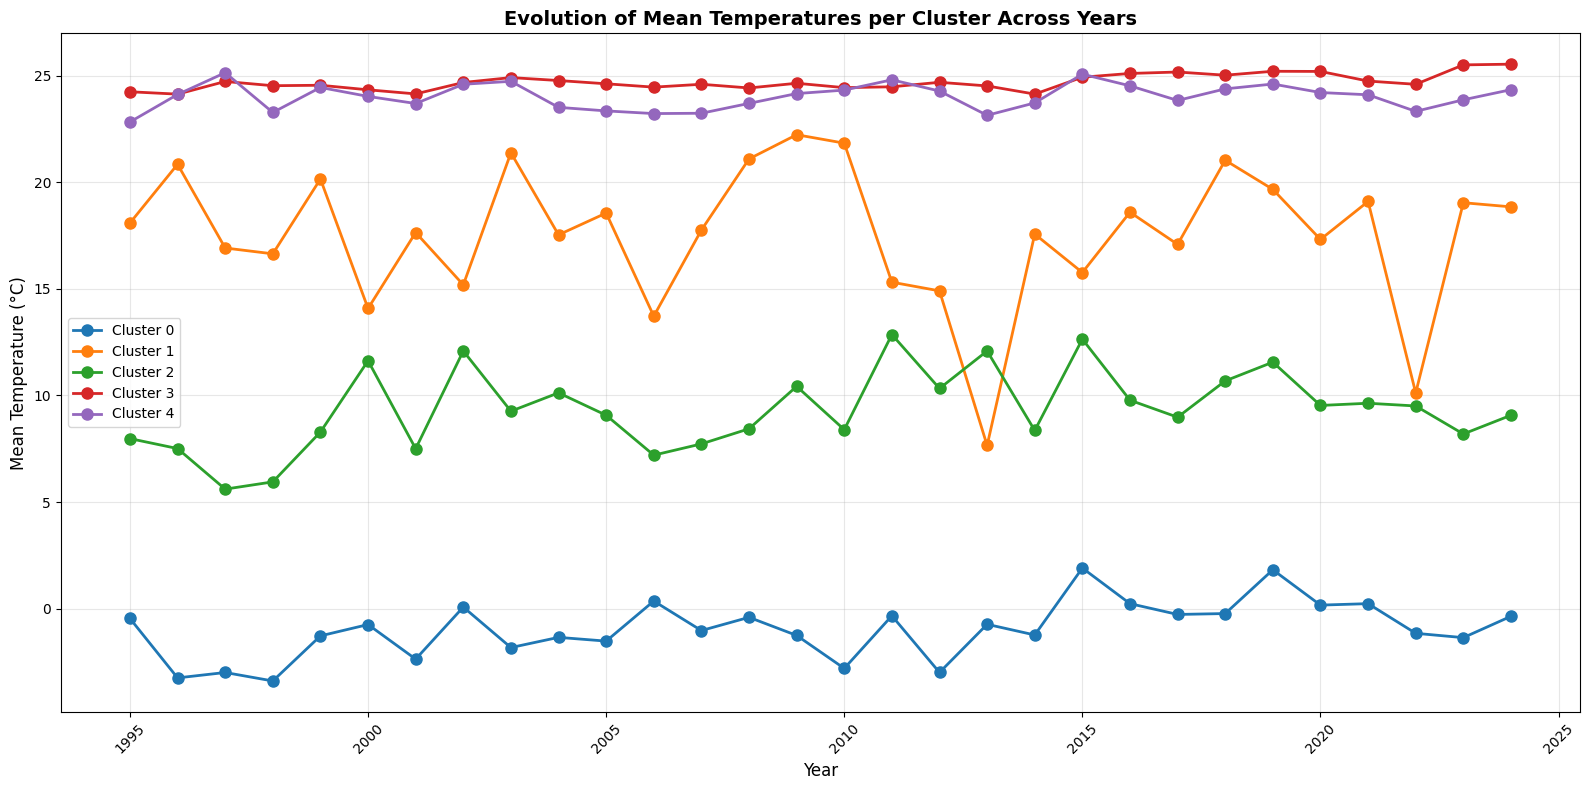

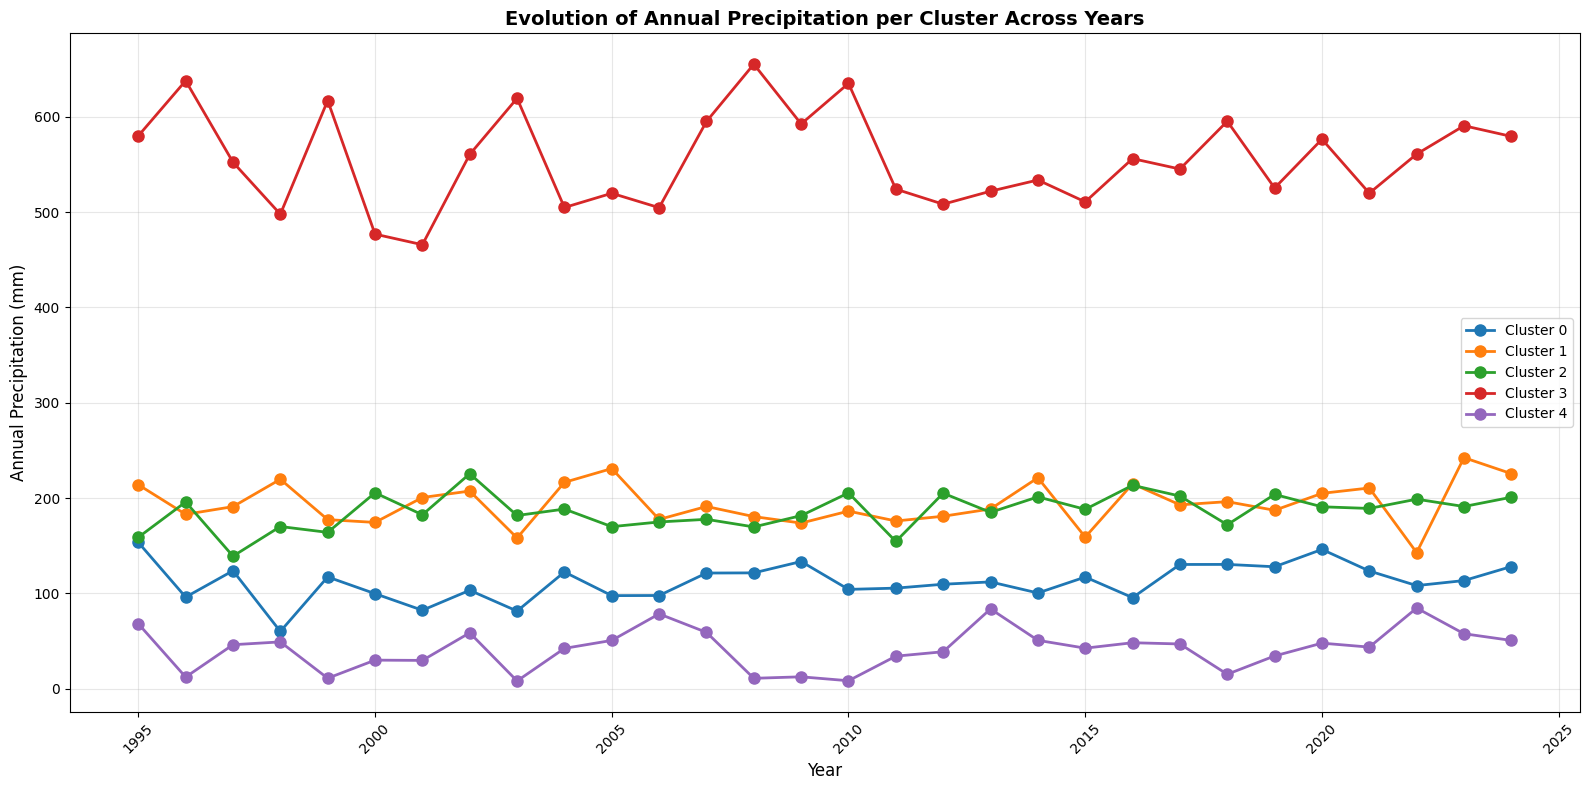

In [ ]:
plot_evo(cluster_means_anni)

# Cluster Distribution

Let analyze which seasons belongs to a given cluster.

The following table indicates how many data points for a given season belong to a cluster.

In [ ]:
def seasonal_cluster_distribution(df):
    # Create a frequency table of seasons vs clusters
    distribution = pd.crosstab(df['season'], df['cluster'], normalize='index') * 100

    # This returns percentages.
    # E.g., What % of Summer assignments belong to Cluster 0?
    return distribution

In [ ]:
df_example = df_clusters_anni[1995]
seasonal_cluster_distribution(df_example)

cluster,0,1,2,3,4
season,,,,,
Autumn,1.226994,3.067485,26.993865,39.263804,29.447853
Spring,1.226994,7.361963,25.766871,32.515337,33.128834
Summer,0.000000,28.220859,2.453988,39.263804,30.061350
Winter,21.472393,3.680982,9.815951,24.539877,40.490798


This heatmap illustrates the seasonal composition of each cluster by detailing the percentage of data points corresponding to a given season assigned to that cluster.

In [ ]:
# 1. Ensure the distribution function is defined
def cluster_seasonal_distribution(df):
    distribution = pd.crosstab(df['season'], df['cluster'], normalize='columns') * 100
    return distribution

# 2. Define the interactive wrapper
def interactive_seasonal_heatmap(df_dict):
    """
    Creates a slider to iterate through years in the dictionary.
    Assumes df_dict is formatted as {year: dataframe}.
    """

    # Extract and sort the available years from your dictionary
    years = sorted(list(df_dict.keys()))

    def plot_for_year(year):
        # Fetch the dataframe for the specific year and calculate distribution
        df = df_dict[year]
        dist_table = cluster_seasonal_distribution(df)

        # Plotting the heatmap
        plt.figure(figsize=(10, 6))
        sns.heatmap(
            dist_table,
            annot=True,
            fmt=".1f",
            cmap="YlOrRd",
            linewidths=0.5,
            vmin=0,         # Lock the minimum color value to 0%
            vmax=100,       # Lock the maximum color value to 100%
            cbar_kws={'label': 'Percentage of Locations (%)'}
        )

        plt.title(f'Seasonal Distribution of Climate Clusters ({year})', fontsize=16, pad=15)
        plt.xlabel('Cluster ID', fontsize=12)
        plt.ylabel('Season', fontsize=12)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    # 3. Build the slider widget
    year_slider = widgets.SelectionSlider(
        options=years,
        value=years[0],
        description='Year:',
        disabled=False,
        continuous_update=True, # Wait until the user stops dragging to update the plot
        orientation='horizontal',
        readout=True
    )

    # 4. Link the slider to the plot
    widgets.interact(plot_for_year, year=year_slider)


In [ ]:
interactive_seasonal_heatmap(df_clusters_anni)

#1 summer-spring, 0 winter, 4 well balanced but more towards winter-summer dicotomy, 2 autumn spring, 3 well balanced

interactive(children=(SelectionSlider(description='Year:', options=(1995, 1996, 1997, 1998, 1999, 2000, 2001, …

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Keep your existing distribution function
def cluster_seasonal_distribution(df):
    distribution = pd.crosstab(df['season'], df['cluster'], normalize='columns') * 100
    return distribution

# 2. Define the new function for the average heatmap
def plot_average_seasonal_heatmap(df_dict):
    """
    Calculates and plots the average seasonal distribution
    across all years in the provided dictionary.
    """
    distributions = []

    # Calculate the percentage distribution for every year
    for year, df in df_dict.items():
        dist_table = cluster_seasonal_distribution(df)
        dist_table.columns = dist_table.columns.astype(int)
        distributions.append(dist_table)

    # Combine all tables and calculate the mean for each season (index)
    # This safely averages the percentages across all years
    combined_dists = pd.concat(distributions)
    avg_dist_table = combined_dists.groupby(combined_dists.index).mean()

    # Extract years to create a dynamic title (e.g., "2010 - 2023")
    years = sorted(list(df_dict.keys()))
    time_span = f"{years[0]} - {years[-1]}" if len(years) > 1 else str(years[0])

    # 3. Plotting the heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        avg_dist_table,
        annot=True,
        fmt=".1f",       # Keep 1 decimal place for the average
        cmap="YlOrRd",
        linewidths=0.5,
        vmin=0,          # Lock the minimum color value to 0%
        vmax=100,        # Lock the maximum color value to 100%
        cbar_kws={'label': 'Average Percentage of Locations (%)'}
    )

    plt.title(f'Average Seasonal Distribution of Climate Clusters ({time_span})', fontsize=16, pad=15)
    plt.xlabel('Cluster ID', fontsize=12)
    plt.ylabel('Season', fontsize=12)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

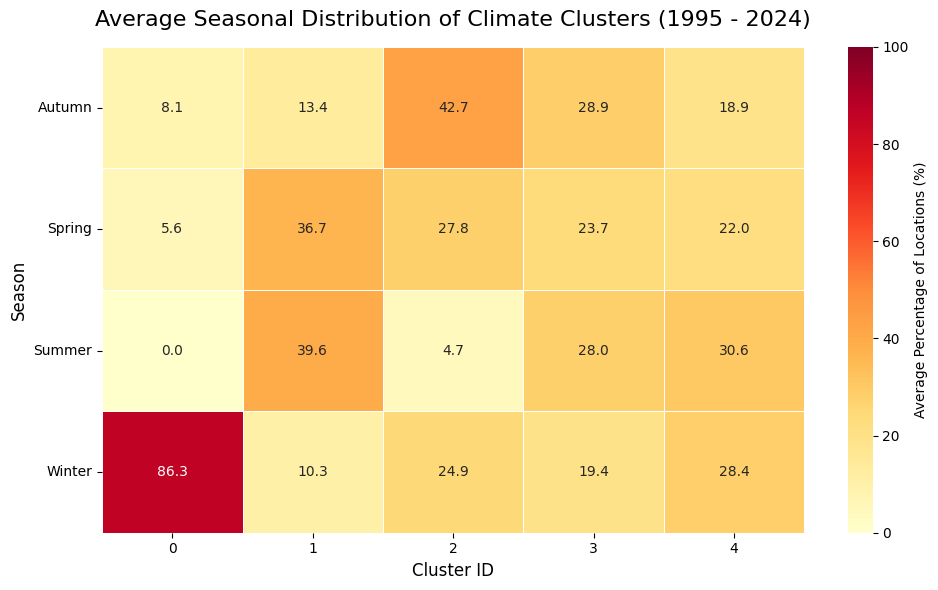

In [ ]:
plot_average_seasonal_heatmap(df_clusters_anni)

# Capitals

Let investigate intra-annual seasonal variability to track whether capitals seasons belong always to same cluster or climate profiles vary a lot during the year.

In [ ]:
def calculate_intra_annual_variability(df):
    # Count unique clusters per capital
    variability = df.groupby('capital')['cluster'].nunique().reset_index()
    variability.columns = ['capital', 'unique_clusters_count']

    # Categorize the variability
    # 1 = Stable all year, 4 = Highly variable
    return variability

In [ ]:
df_example = df_clusters_anni[1995]
variability_df = calculate_intra_annual_variability(df_example)

display(variability_df)

,capital,unique_clusters_count
0,Abuja,2
1,Accra,2
2,Addis Ababa,2
3,Algiers,3
4,Alofi,1
...,...,...
158,Yamoussoukro,2
159,Yaoundé,1
160,Yaren District,2
161,Yerevan,2


In [ ]:
def plot_city_cluster_matrix(df_dict, city_name, colors_to_use=my_colors):
    """
    Plots a Season x Year grid for a single city showing cluster trajectory.
    """
    # 1. Combine all years into one DataFrame
    records = []
    for year, df in df_dict.items():
        df_year = df.copy()
        df_year['year'] = year
        records.append(df_year)

    full_df = pd.concat(records, ignore_index=True)

    # Filter for the target city
    city_df = full_df[full_df['capital'] == city_name].copy()

    if city_df.empty:
        print(f"No data found for city: {city_name}")
        return

    # 2. Extract color values
    colors_list = list(colors_to_use.values())

    # 3. Enforce standard seasonal order
    season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
    city_df['season'] = pd.Categorical(city_df['season'], categories=season_order, ordered=True)

    # 4. Pivot table: Rows = Seasons, Columns = Years
    pivot_df = city_df.pivot(index='season', columns='year', values='cluster')

    # Convert cluster values to numeric floats/ints
    pivot_df = pivot_df.apply(pd.to_numeric, errors='coerce')

    # 5. Plot discrete heatmap
    plt.figure(figsize=(14, 4))

    cmap = ListedColormap(colors_list)

    sns.heatmap(
        pivot_df,
        annot=True,              # Print cluster number inside the cell
        fmt=".0f",               # Formats numbers cleanly (handles ints/floats)
        cmap=cmap,
        vmin=0,
        vmax=len(colors_list) - 0.01,
        linewidths=1.5,
        linecolor='white',
        cbar=False,              # Hide colorbar since colors match cluster IDs directly
        mask=pivot_df.isna()     # Masks out any missing data safely
    )

    plt.title(f'Seasonal Cluster Trajectory: {city_name}', fontsize=15, pad=15)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Season', fontsize=12)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [ ]:
def interactive_city_viewer(df_dict, colors_to_use=my_colors):
    """
    Creates an interactive dropdown menu to select any city.
    """
    # Grab unique cities from the first year's DataFrame
    first_year = next(iter(df_dict.keys()))
    cities = sorted(df_dict[first_year]['capital'].dropna().unique().tolist())

    city_dropdown = widgets.Dropdown(
        options=cities,
        value=cities[0],
        description='City:',
        disabled=False
    )

    widgets.interact(
        lambda city: plot_city_cluster_matrix(df_dict, city, colors_to_use),
        city=city_dropdown
    )

In [ ]:
interactive_city_viewer(df_clusters_anni)

interactive(children=(Dropdown(description='City:', options=('Abuja', 'Accra', 'Addis Ababa', 'Algiers', 'Alof…

# PCA analysis

Finally, let plot in two dimensions the pair *city-season* to validate the overall clustering procedure.

In [ ]:
def plot_PCA(
    df_cluster_assignment,
    year,
    colors_to_use=my_colors,
    capitals=[
        'Rome', 'Ottawa', 'Tokyo', 'Moscow', 'Mexico City',
        'Windhoek', 'Berlin', 'Luanda', 'Jakarta', 'Lima',
        'Santiago', 'Canberra', 'New Delhi', 'Algiers', 'Nuuk', 'La Paz'
    ],
    season='Summer'
):

    df_year = df_cluster_assignment[df_cluster_assignment['year'] == year].copy()
    df_year = df_year[df_year['season'] == season].copy()

    numerical_cols = df_year.select_dtypes(include=[np.number]).columns.tolist()
    numerical_cols = [c for c in numerical_cols if c not in ['year', 'cluster']]

    df_numeric = df_year[numerical_cols].dropna()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_numeric)

    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(X_scaled)

    df_year.loc[df_numeric.index, 'pca1'] = pca_result[:, 0]
    df_year.loc[df_numeric.index, 'pca2'] = pca_result[:, 1]

    print("\nExplained variance:")
    print(f"PC1: {pca.explained_variance_ratio_[0]:.1%}")
    print(f"PC2: {pca.explained_variance_ratio_[1]:.1%}")
    print(f"Total: {pca.explained_variance_ratio_.sum():.1%}")

    plt.figure(figsize=(14, 10))

    for cluster_id in sorted(df_year['cluster'].dropna().unique()):
        cluster_data = df_year[df_year['cluster'] == cluster_id]

        plt.scatter(
            cluster_data['pca1'],
            cluster_data['pca2'],
            c=colors_to_use[int(cluster_id)],
            label=f'Cluster {cluster_id}',
            alpha=0.7,
            s=120,
            edgecolors='black',
            linewidth=0.8
        )

    for capital in capitals:
        row = df_year[df_year["capital"] == capital]
        row = row[row["season"] == season]

        if not row.empty and not pd.isna(row['pca1'].values[0]):
            plt.annotate(
                capital,
                (row['pca1'].values[0], row['pca2'].values[0]),
                fontsize=9,
                alpha=0.9,
                fontweight='bold'
            )

    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)',
               fontsize=12, fontweight='bold')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)',
               fontsize=12, fontweight='bold')
    plt.title(f'PCA Projection of Climate Clusters - {year}',
              fontsize=14, fontweight='bold')

    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Explained variance:
PC1: 50.2%
PC2: 19.3%
Total: 69.5%


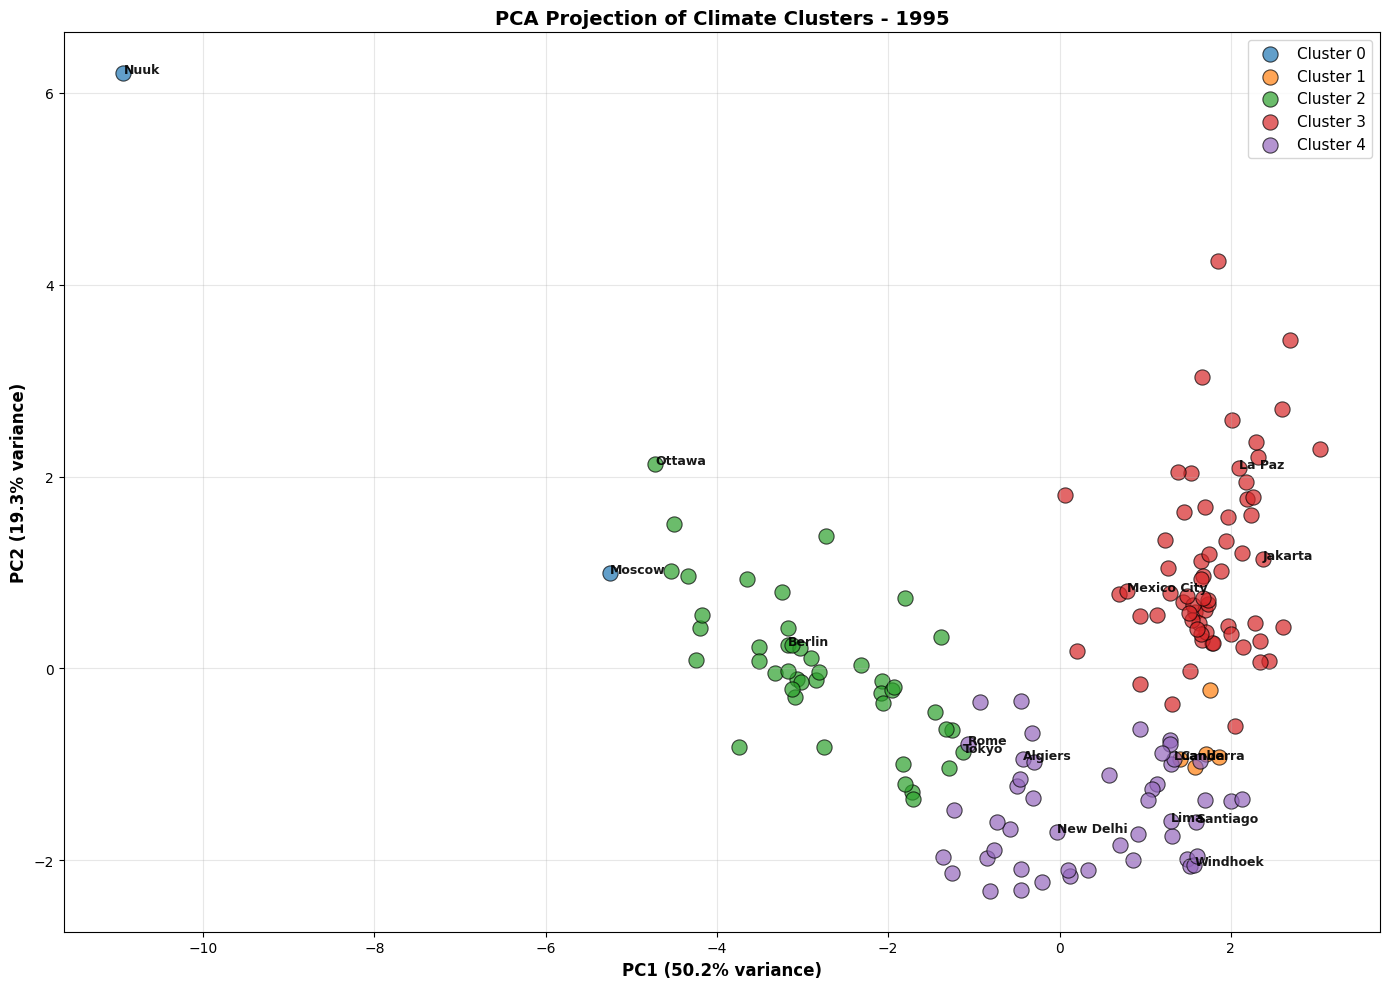


Explained variance:
PC1: 49.5%
PC2: 19.3%
Total: 68.8%


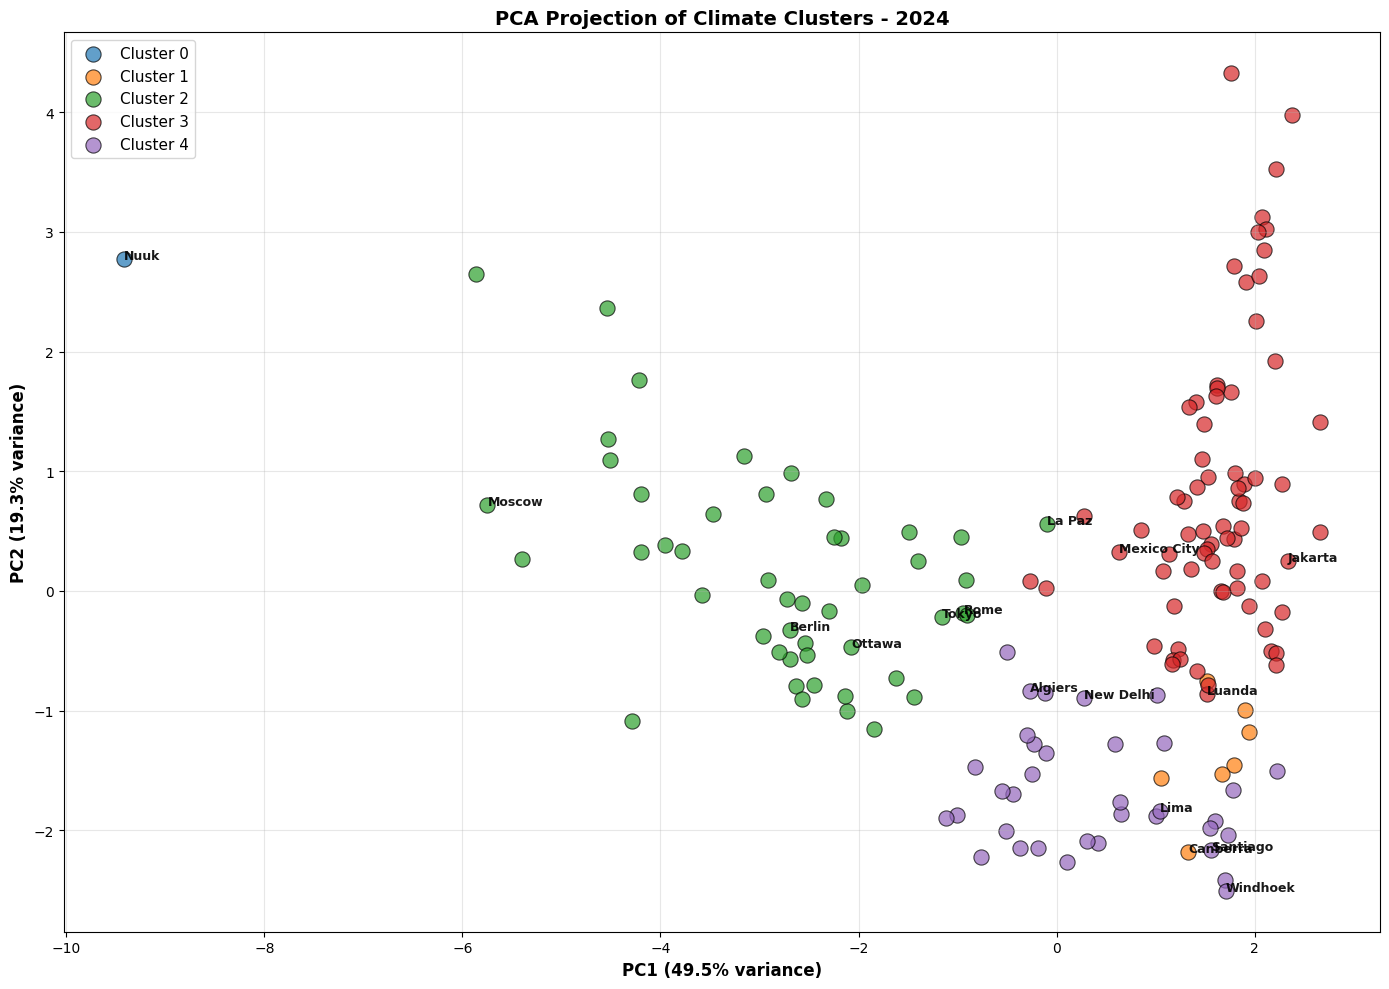

In [ ]:
year_1, year_2 = 1995, 2024

plot_PCA(df_clusters_anni[year_1], year_1, season="Autumn")
plot_PCA(df_clusters_anni[year_2], year_2, season="Autumn")

In [ ]:
def plot_city_trajectories_pca(df_clusters_dict, years, features, capitals_to_plot, colors_to_use=my_colors, season="Winter"):

    print("="*100)
    print("CLIMATE TRAJECTORY ANALYSIS (GLOBAL PCA)")
    print("="*100)

    all_data = []
    for year in years:
        df_temp = df_clusters_dict[year].copy()
        df_temp['year'] = year
        df_temp = df_temp[df_temp['season'] == season]
        all_data.append(df_temp)

    full_df = pd.concat(all_data, ignore_index=True)
    full_df['cluster'] = pd.to_numeric(full_df['cluster'], errors='coerce')

    X = full_df[features].copy()

    for col in ['rain_total', 'snow_total']:
        if col in X.columns:
            X[col] = np.log1p(X[col])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2)
    coords = pca.fit_transform(X_scaled)

    full_df['pc1'] = coords[:, 0]
    full_df['pc2'] = coords[:, 1]

    print(f"Explained variance: PC1 {pca.explained_variance_ratio_[0]:.1%} | PC2 {pca.explained_variance_ratio_[1]:.1%}")

    plt.figure(figsize=(16, 12))

    for cluster_id in sorted(full_df['cluster'].dropna().unique()):
        cluster_id_int = int(cluster_id)
        cluster_data = full_df[full_df['cluster'] == cluster_id]
        plt.scatter(
            cluster_data['pc1'],
            cluster_data['pc2'],
            c=colors_to_use[cluster_id_int],
            alpha=0.05,
            s=30
        )

    for capital in capitals_to_plot:
        cap_data = full_df[full_df['capital'] == capital].sort_values('year')
        cap_data = cap_data[cap_data["season"] == season]

        if cap_data.empty:
            print(f"Warning: {capital} not found in the data.")
            continue

        plt.plot(
            cap_data['pc1'],
            cap_data['pc2'],
            color='black',
            alpha=0.3,
            linewidth=1,
            zorder=2
        )

        for _, row in cap_data.iterrows():
            if pd.notna(row['cluster']):
                plt.scatter(
                    row['pc1'],
                    row['pc2'],
                    color=colors_to_use[int(row['cluster'])],
                    s=80,
                    edgecolor='black',
                    linewidth=0.5,
                    zorder=3
                )

        start_row = cap_data.iloc[0]
        end_row = cap_data.iloc[-1]

        start_yr = str(start_row['year'])[-2:]
        end_yr = str(end_row['year'])[-2:]

        plt.text(start_row['pc1'], start_row['pc2'], f"{capital}\n'{start_yr}", fontsize=9, fontweight='bold', ha='right')
        plt.text(end_row['pc1'], end_row['pc2'], f"'{end_yr}", fontsize=9, fontweight='bold', color='red')

    min_yr = min(years)
    max_yr = max(years)
    plt.title(f'Capital Climate Trajectories ({min_yr}-{max_yr}) - PCA Projection ({season})', fontsize=16)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
    plt.grid(True, alpha=0.3)

    present_clusters = sorted([int(c) for c in full_df['cluster'].dropna().unique()])
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=f'Cluster {k}',
               markerfacecolor=colors_to_use[k], markersize=10, markeredgecolor='k')
        for k in present_clusters if k in colors_to_use
    ]

    plt.legend(handles=legend_elements, title="Cluster Assignment", loc='upper right')
    plt.tight_layout()
    plt.show()

CLIMATE TRAJECTORY ANALYSIS (GLOBAL PCA)
Explained variance: PC1 32.9% | PC2 25.9%


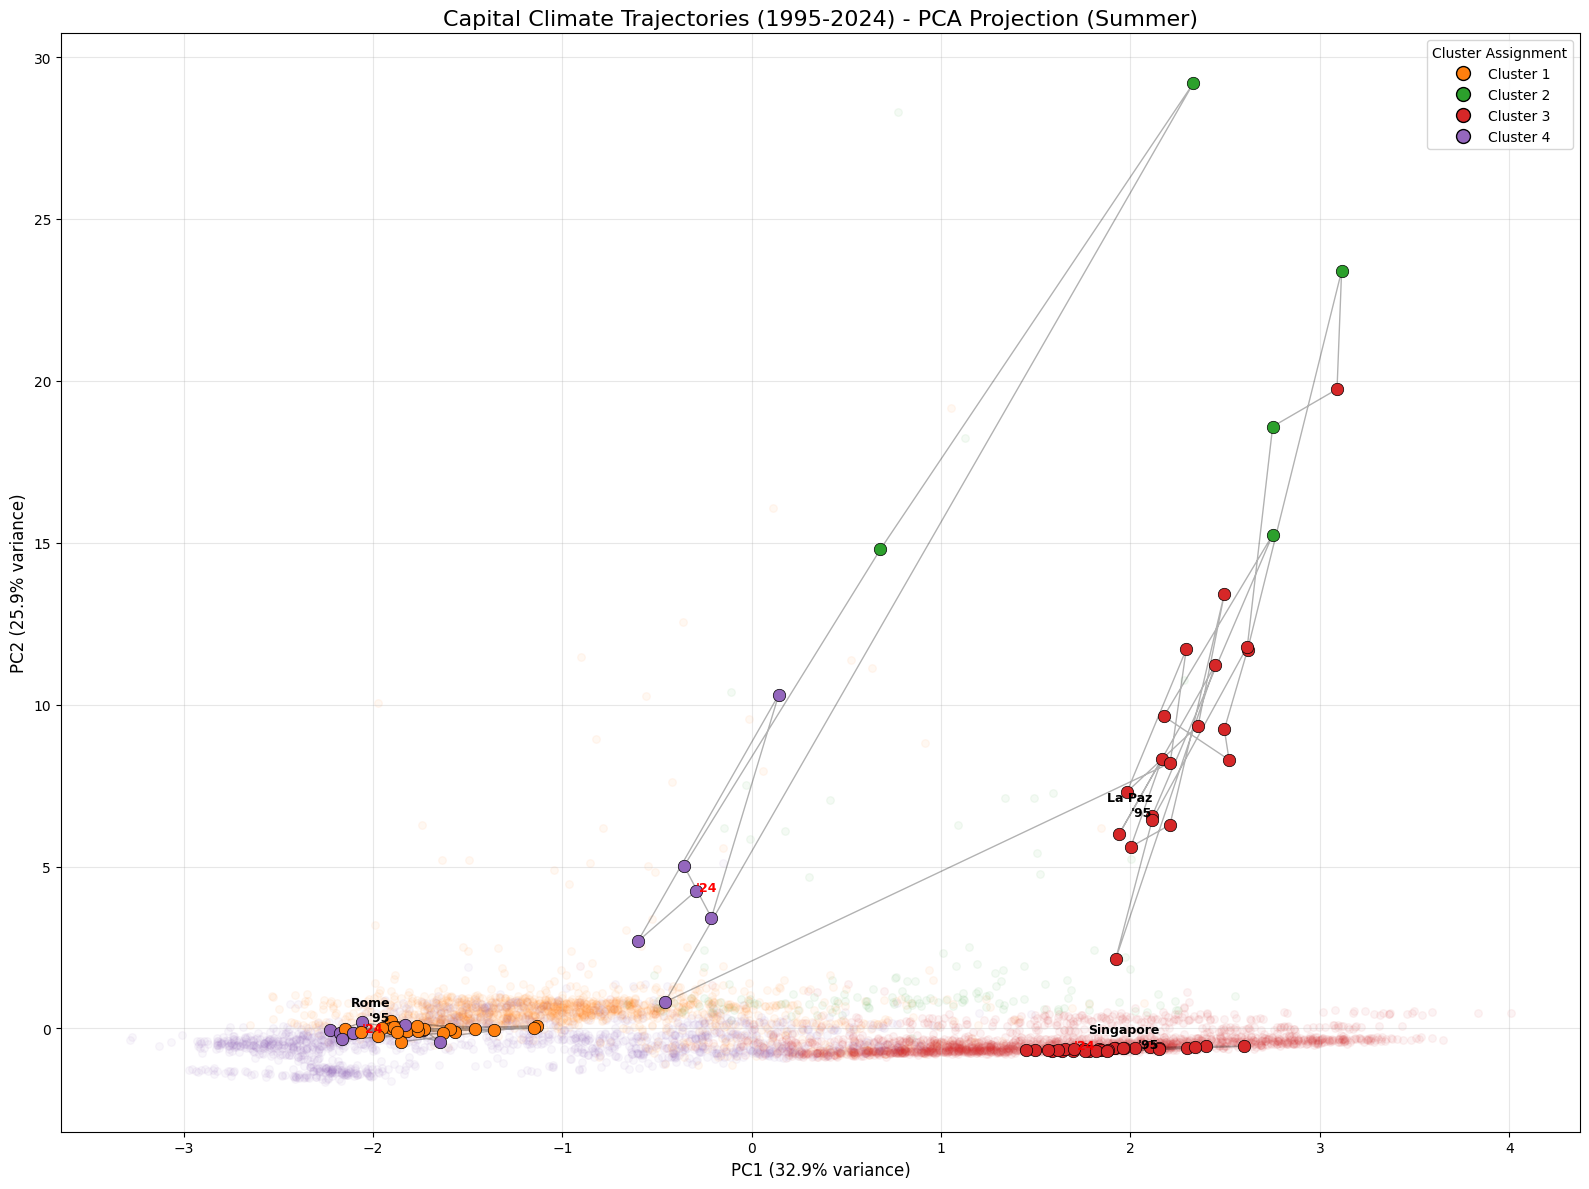

In [ ]:
capitals_selection = ['Rome', 'Singapore', 'La Paz']

plot_city_trajectories_pca(df_clusters_anni, years, features, capitals_selection, season="Summer")

# Conclusion
- cluster profile
- cluster distribution
- capital season variability